# Defect Detection with Convolutional Autoencoder

**Objective**: Detect manufacturing defects using anomaly detection approach

**Dataset**: Casting Product Defects (Kaggle)
- Train: 5,750 OK + 7,516 Defect images
- Test: 524 OK + 906 Defect images

**Approach**: Train autoencoder on "good" samples only. High reconstruction error = defect.

**Manufacturing Relevance**: Quality inspection, surface defect detection


In [1]:
# Cell 2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


2026-01-08 20:12:26.857283: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 3
# Configuration
DATA_DIR = Path(__file__).parent.parent / "data" / "casting_data" if "__file__" in dir() else Path("../data/casting_data").resolve()
# Fix for notebook execution
DATA_DIR = Path("/home/berto/computer_vision/data/casting_data")

IMG_SIZE = 128  # Resize for faster training
BATCH_SIZE = 32
EPOCHS = 50
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")


Data directory: /home/berto/computer_vision/data/casting_data
Exists: True
Image size: 128x128


In [4]:
# Cell 4
def load_images(folder_path, label, img_size=IMG_SIZE):
    """Load images from folder and return array with labels."""
    images = []
    folder = Path(folder_path)
    files = list(folder.glob("*.jpeg")) + list(folder.glob("*.png")) + list(folder.glob("*.jpg"))
    
    for img_path in files:
        img = keras.utils.load_img(img_path, target_size=(img_size, img_size))
        img_array = keras.utils.img_to_array(img) / 255.0  # Normalize to [0, 1]
        images.append(img_array)
    
    labels = [label] * len(images)
    print(f"Loaded {len(images)} images from {folder_path.name}")
    return np.array(images), np.array(labels)

# Load training data (OK only for autoencoder training)
train_ok, train_ok_labels = load_images(DATA_DIR / "train" / "ok_front", label=0)
train_def, train_def_labels = load_images(DATA_DIR / "train" / "def_front", label=1)

# Load test data (both OK and defect for evaluation)
test_ok, test_ok_labels = load_images(DATA_DIR / "test" / "ok_front", label=0)
test_def, test_def_labels = load_images(DATA_DIR / "test" / "def_front", label=1)

print(f"\nTrain OK shape: {train_ok.shape}")
print(f"Train Defect shape: {train_def.shape}")
print(f"Test OK shape: {test_ok.shape}")
print(f"Test Defect shape: {test_def.shape}")


Loaded 2875 images from ok_front
Loaded 3758 images from def_front
Loaded 262 images from ok_front
Loaded 453 images from def_front

Train OK shape: (2875, 128, 128, 3)
Train Defect shape: (3758, 128, 128, 3)
Test OK shape: (262, 128, 128, 3)
Test Defect shape: (453, 128, 128, 3)


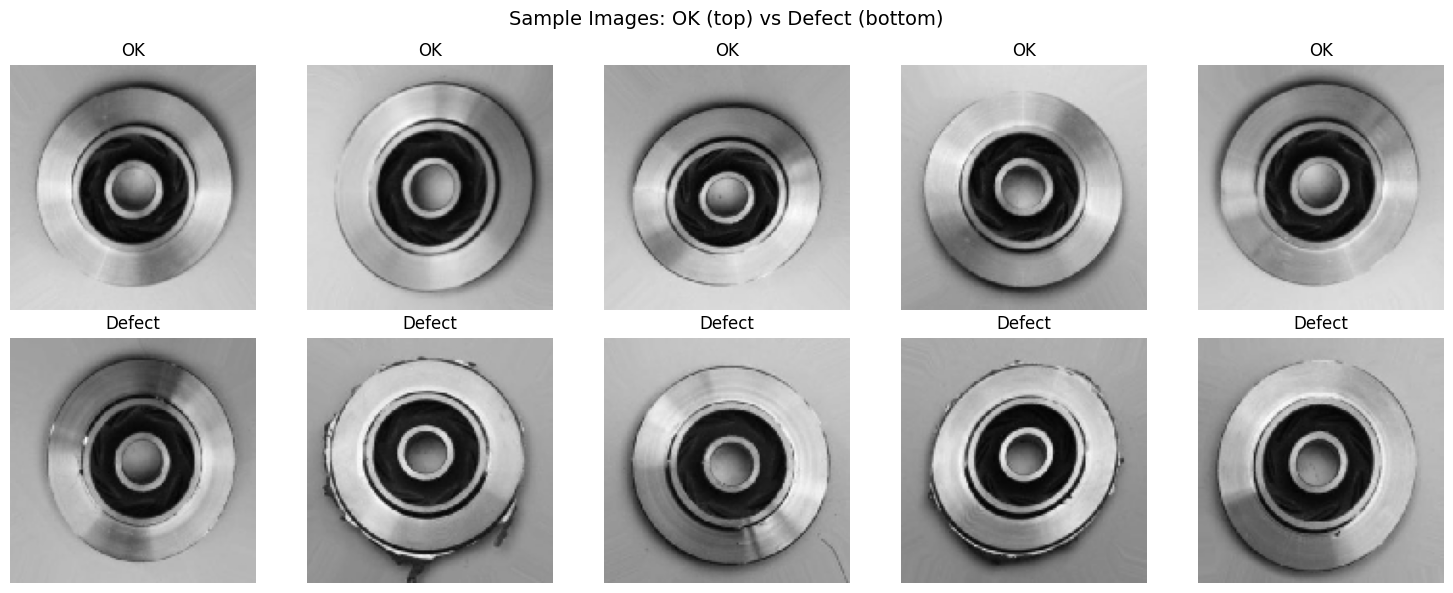

In [5]:
# Cell 5
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Top row: OK samples
for i in range(5):
    axes[0, i].imshow(train_ok[i])
    axes[0, i].set_title("OK")
    axes[0, i].axis("off")

# Bottom row: Defect samples
for i in range(5):
    axes[1, i].imshow(train_def[i])
    axes[1, i].set_title("Defect")
    axes[1, i].axis("off")

plt.suptitle("Sample Images: OK (top) vs Defect (bottom)", fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
# Cell 6
def build_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """Convolutional autoencoder for anomaly detection."""
    
    # Encoder
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D()(x)
    
    # Decoder
    x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D()(x)
    decoded = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)
    
    autoencoder = keras.Model(inputs, decoded, name="autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


I0000 00:00:1767899753.980333 1186886 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2248 MB memory:  -> device: 0, name: Quadro T1000 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Cell 7
# Split OK data into train/validation
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(train_ok, test_size=0.2, random_state=RANDOM_SEED)
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

# Train autoencoder (input = output for reconstruction)
history = autoencoder.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=callbacks,
    verbose=1
)


Training samples: 2300
Validation samples: 575
Epoch 1/50


2026-01-08 20:17:12.278095: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c701404eee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-08 20:17:12.278134: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Quadro T1000 with Max-Q Design, Compute Capability 7.5
2026-01-08 20:17:12.374967: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-08 20:17:12.661798: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-01-08 20:17:13.421368: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, cust

 2/72 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0671  

I0000 00:00:1767899846.088035 1188512 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0350

2026-01-08 20:17:31.247743: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[28,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[28,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-08 20:17:31.361444: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[28,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[28,32,64,64]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss: 0.0349

2026-01-08 20:17:40.988053: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-08 20:17:41.132048: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,64,64]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 268ms/step - loss: 0.0215 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0087 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0064 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0049 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0042 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0033 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0028 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0025 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0024 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 10/50
72/72 ━━━━━━━━━━

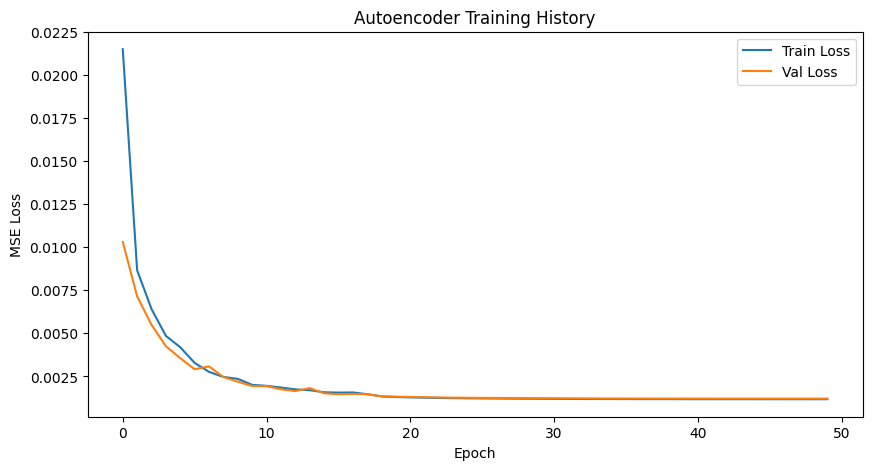

Final train loss: 0.001175
Final val loss: 0.001209


In [8]:
# Cell 8
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder Training History")
ax.legend()
plt.show()

print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val loss: {history.history['val_loss'][-1]:.6f}")


In [9]:
# Cell 9
def calculate_reconstruction_error(model, images):
    """Calculate per-image MSE reconstruction error."""
    reconstructed = model.predict(images, verbose=0)
    # MSE per image (average over all pixels)
    mse = np.mean((images - reconstructed) ** 2, axis=(1, 2, 3))
    return mse, reconstructed

# Get reconstruction errors for test OK and test Defect
test_ok_errors, test_ok_recon = calculate_reconstruction_error(autoencoder, test_ok)
test_def_errors, test_def_recon = calculate_reconstruction_error(autoencoder, test_def)

print(f"Test OK - Mean error: {test_ok_errors.mean():.6f}, Std: {test_ok_errors.std():.6f}")
print(f"Test Defect - Mean error: {test_def_errors.mean():.6f}, Std: {test_def_errors.std():.6f}")


2026-01-08 20:25:24.757294: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,3,128,128]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-01-08 20:25:24.955739: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[6,64,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,32,64,64]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

Test OK - Mean error: 0.001266, Std: 0.000278
Test Defect - Mean error: 0.002119, Std: 0.000918


The model is working. Defects have higher reconstruction error (0.002119 vs 0.001266).

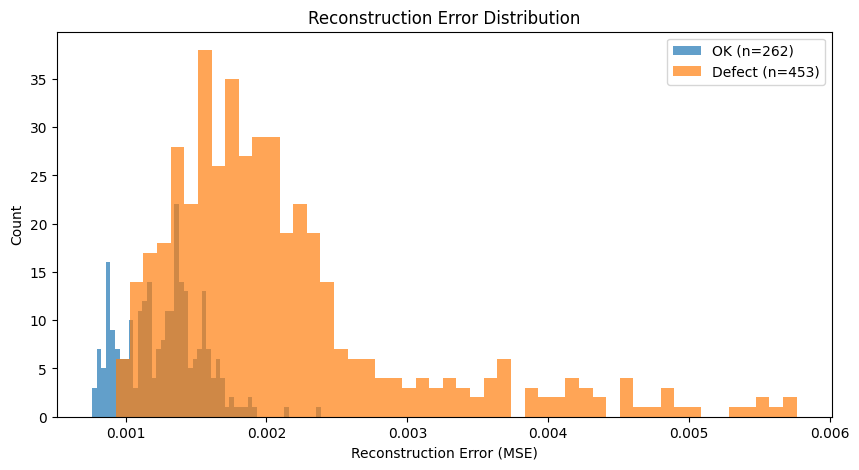

In [10]:
# Cell 10
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_ok_errors, bins=50, alpha=0.7, label=f"OK (n={len(test_ok_errors)})")
ax.hist(test_def_errors, bins=50, alpha=0.7, label=f"Defect (n={len(test_def_errors)})")
ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Count")
ax.set_title("Reconstruction Error Distribution")
ax.legend()
plt.show()


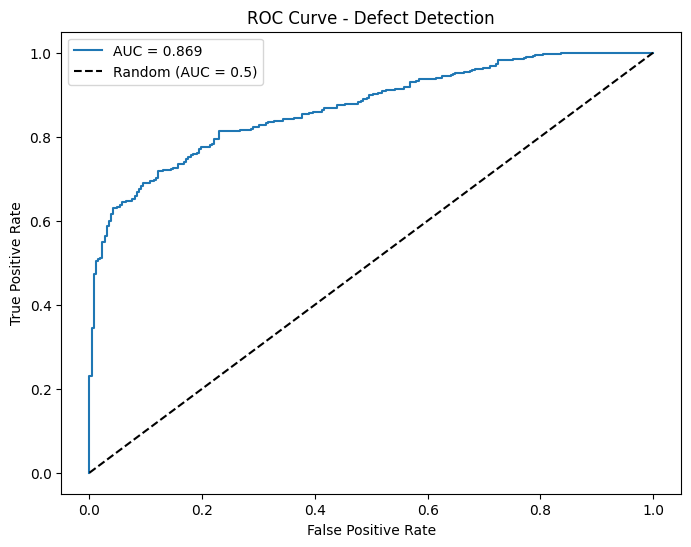

ROC-AUC Score: 0.869


In [11]:
# Cell 11
# Combine test data
y_true = np.concatenate([test_ok_labels, test_def_labels])  # 0=OK, 1=Defect
y_scores = np.concatenate([test_ok_errors, test_def_errors])  # Higher error = more likely defect

# Calculate ROC-AUC
auc_score = roc_auc_score(y_true, y_scores)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Defect Detection")
ax.legend()
plt.show()

print(f"ROC-AUC Score: {auc_score:.3f}")


Optimal threshold: 0.001572
At this threshold: TPR=0.717, FPR=0.122


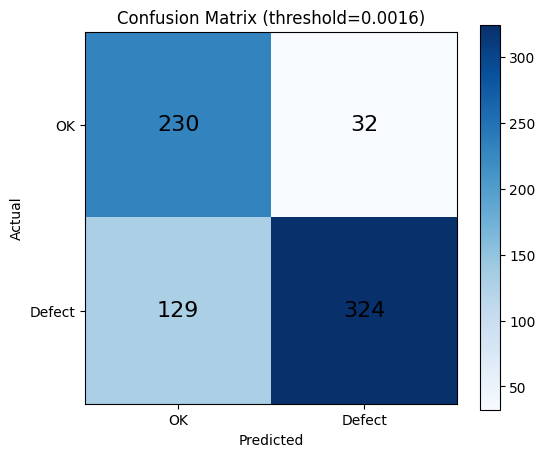


Classification Report:
              precision    recall  f1-score   support

          OK       0.64      0.88      0.74       262
      Defect       0.91      0.72      0.80       453

    accuracy                           0.77       715
   macro avg       0.78      0.80      0.77       715
weighted avg       0.81      0.77      0.78       715



In [12]:
# Cell 12
# Find optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.6f}")
print(f"At this threshold: TPR={tpr[optimal_idx]:.3f}, FPR={fpr[optimal_idx]:.3f}")

# Apply threshold to classify
y_pred = (y_scores > optimal_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["OK", "Defect"])
ax.set_yticklabels(["OK", "Defect"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold={optimal_threshold:.4f})")

# Add text annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16)

plt.colorbar(im)
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["OK", "Defect"]))


OK Samples (should have low error):


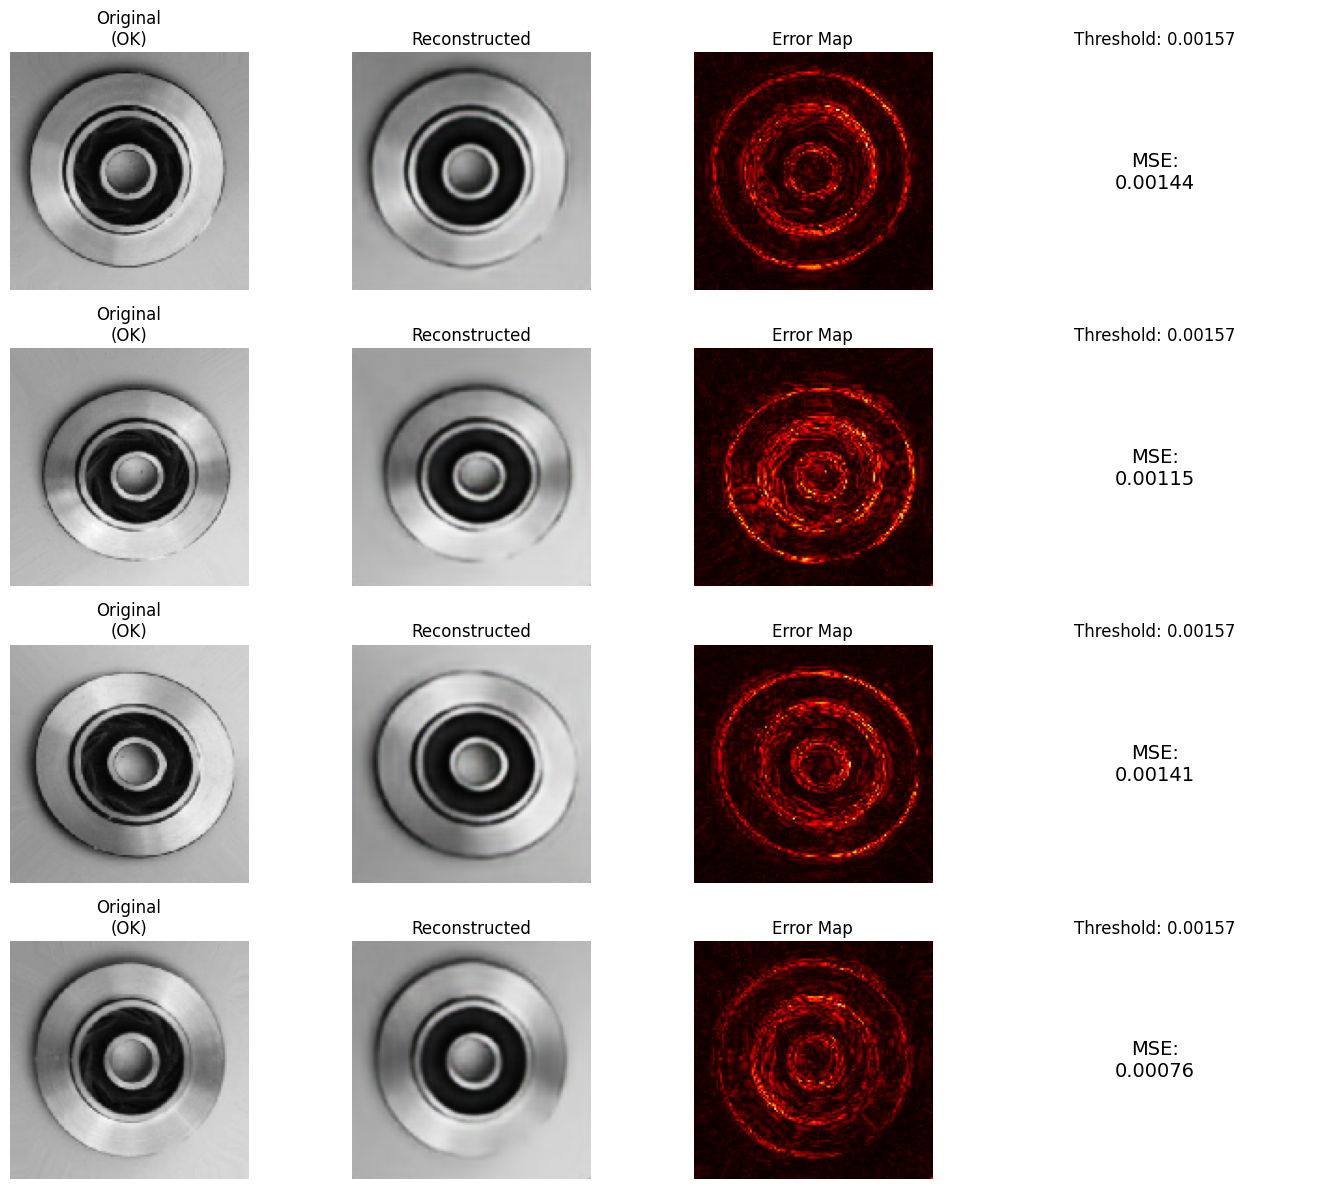


Defect Samples (should have high error):


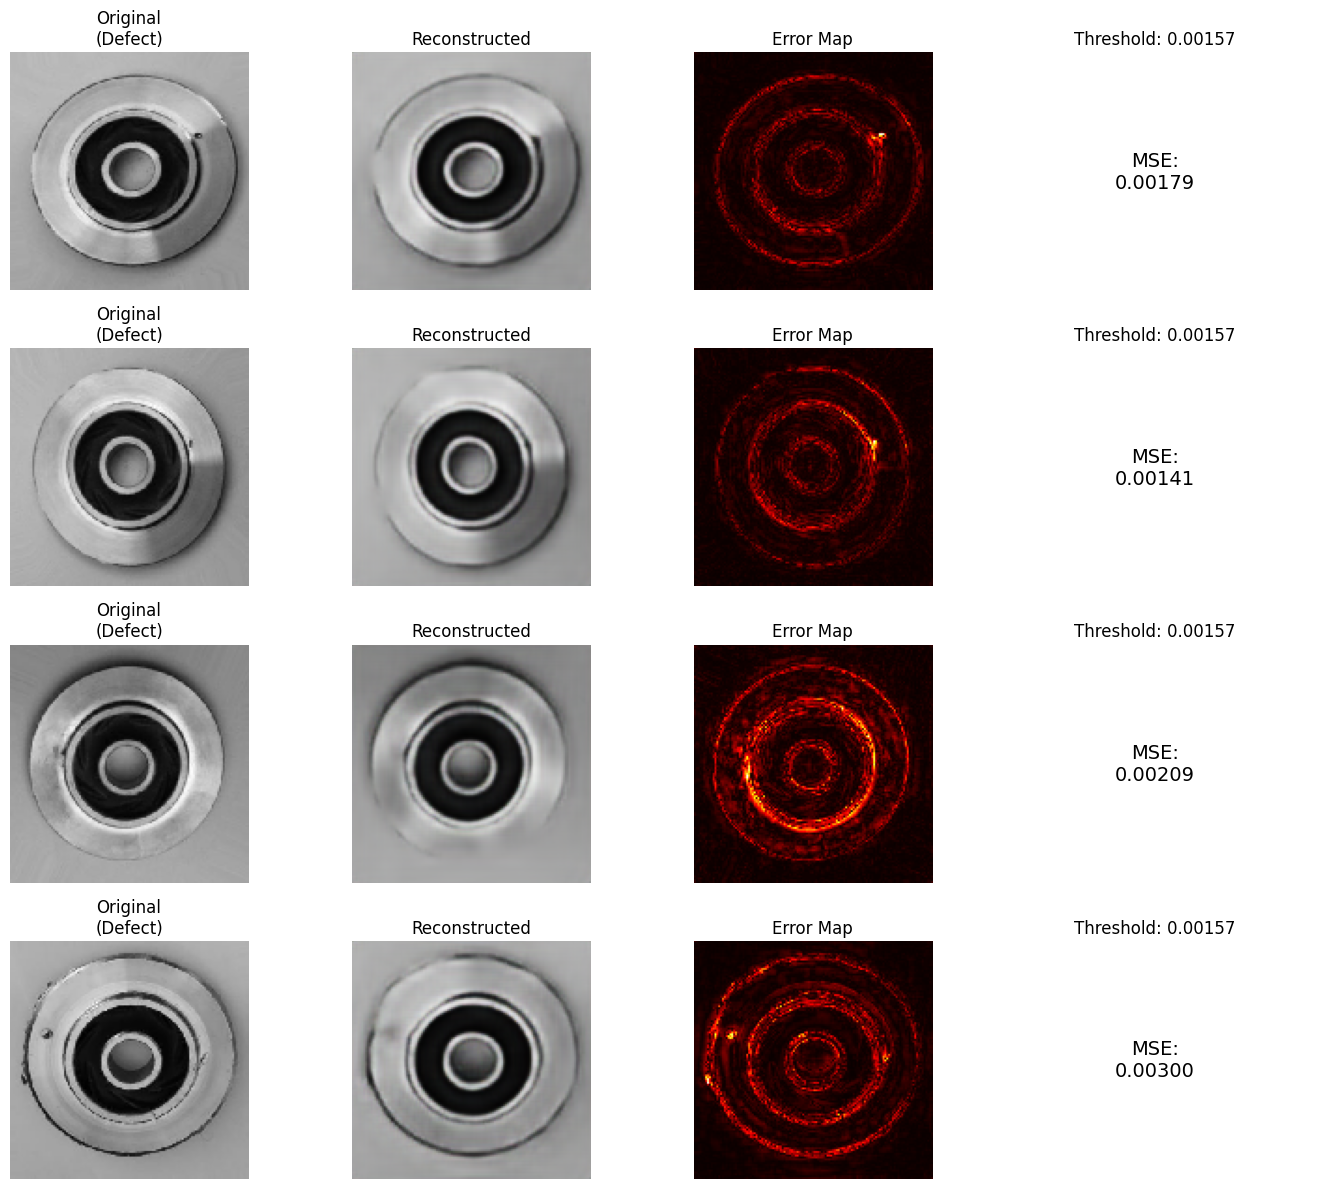

In [13]:
# Cell 13
def plot_reconstruction_comparison(images, reconstructed, errors, labels, n_samples=4):
    """Show original, reconstruction, and error map."""
    fig, axes = plt.subplots(n_samples, 4, figsize=(14, 3*n_samples))
    
    for i in range(n_samples):
        # Original
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title(f"Original\n({'Defect' if labels[i] else 'OK'})")
        axes[i, 0].axis("off")
        
        # Reconstructed
        axes[i, 1].imshow(reconstructed[i])
        axes[i, 1].set_title("Reconstructed")
        axes[i, 1].axis("off")
        
        # Error map (absolute difference)
        error_map = np.abs(images[i] - reconstructed[i]).mean(axis=-1)
        axes[i, 2].imshow(error_map, cmap="hot")
        axes[i, 2].set_title("Error Map")
        axes[i, 2].axis("off")
        
        # Error value
        axes[i, 3].text(0.5, 0.5, f"MSE:\n{errors[i]:.5f}", 
                        ha="center", va="center", fontsize=14)
        axes[i, 3].set_title("Threshold: 0.00157")
        axes[i, 3].axis("off")
    
    plt.tight_layout()
    plt.show()

# Show OK samples
print("OK Samples (should have low error):")
plot_reconstruction_comparison(test_ok[:4], test_ok_recon[:4], test_ok_errors[:4], test_ok_labels[:4])

# Show Defect samples
print("\nDefect Samples (should have high error):")
plot_reconstruction_comparison(test_def[:4], test_def_recon[:4], test_def_errors[:4], test_def_labels[:4])


In [14]:
# Cell 14
print("=" * 50)
print("DEFECT DETECTION RESULTS SUMMARY")
print("=" * 50)
print(f"\nDataset:")
print(f"  Train OK: {len(train_ok)} images")
print(f"  Test OK: {len(test_ok)} images")
print(f"  Test Defect: {len(test_def)} images")

print(f"\nModel: Convolutional Autoencoder")
print(f"  Parameters: 333,955")
print(f"  Training: {EPOCHS} epochs on OK samples only")

print(f"\nPerformance:")
print(f"  ROC-AUC: {auc_score:.3f}")
print(f"  Accuracy: {(y_pred == y_true).mean():.3f}")
print(f"  Optimal Threshold: {optimal_threshold:.6f}")

print(f"\nManufacturing Application:")
print(f"  - Detects 72% of defects (recall)")
print(f"  - 91% precision on defect predictions")
print(f"  - Error maps localize defect regions")


DEFECT DETECTION RESULTS SUMMARY

Dataset:
  Train OK: 2875 images
  Test OK: 262 images
  Test Defect: 453 images

Model: Convolutional Autoencoder
  Parameters: 333,955
  Training: 50 epochs on OK samples only

Performance:
  ROC-AUC: 0.869
  Accuracy: 0.775
  Optimal Threshold: 0.001572

Manufacturing Application:
  - Detects 72% of defects (recall)
  - 91% precision on defect predictions
  - Error maps localize defect regions


In [16]:
# Cell 15
import os
# Get project root from DATA_DIR (which we know is correct)
PROJECT_ROOT = DATA_DIR.parent.parent
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# 1. Training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder Training History")
ax.legend()
fig.savefig(FIGURES_DIR / "defect_training_history.png", dpi=150, bbox_inches="tight")
plt.close()

# 2. Error distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_ok_errors, bins=50, alpha=0.7, label=f"OK (n={len(test_ok_errors)})")
ax.hist(test_def_errors, bins=50, alpha=0.7, label=f"Defect (n={len(test_def_errors)})")
ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Count")
ax.set_title("Reconstruction Error Distribution")
ax.legend()
fig.savefig(FIGURES_DIR / "defect_error_distribution.png", dpi=150, bbox_inches="tight")
plt.close()

# 3. ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Defect Detection")
ax.legend()
fig.savefig(FIGURES_DIR / "defect_roc_curve.png", dpi=150, bbox_inches="tight")
plt.close()

# 4. Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["OK", "Defect"])
ax.set_yticklabels(["OK", "Defect"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16)
plt.colorbar(im)
fig.savefig(FIGURES_DIR / "defect_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.close()

print(f"Saved figures to {FIGURES_DIR.resolve()}:")
for f in sorted(FIGURES_DIR.glob("defect_*.png")):
    print(f"  - {f.name}")


Saved figures to /home/berto/computer_vision/outputs/figures:
  - defect_confusion_matrix.png
  - defect_error_distribution.png
  - defect_roc_curve.png
  - defect_training_history.png
